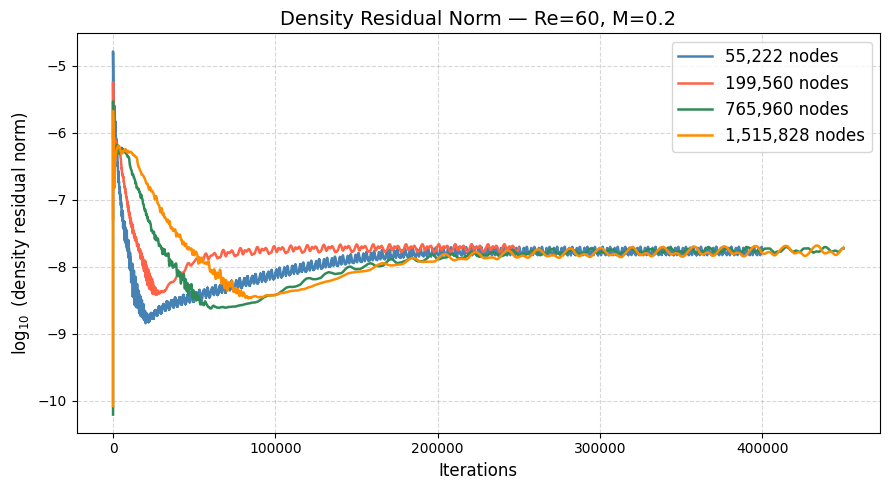

In [3]:
import numpy as np
import matplotlib.pyplot as plt
 
# ── Parameters ─────────────────────────────────────────────────────────────────
RE    = 60
MACH  = 0.2
gamma = 1.4
R_gas = 287.0

# farfield conditions — must match solver values
T_inf   = 288.15
P_inf   = 1.32702          # Pa
rho_inf = P_inf / (R_gas * T_inf)
u_inf   = MACH * np.sqrt(gamma * R_gas * T_inf)
q_inf   = 0.5 * rho_inf * u_inf**2   # dynamic pressure for Cp

# ── Mesh list — update to your actual sizes ────────────────────────────────────
mesh_list = [55222, 199560, 765960, 1515828]
# mesh_list = [1515828]
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']
base_dir  = "/home/ahf25/CFD_2d_cylinder_all/Steady/Ma0.2/v3_mesh"
wall_flag = 7
fig, ax = plt.subplots(figsize=(9, 5))

for mesh, color in zip(mesh_list, colors):
    try:
        case_dir  = f"{base_dir}/2d_cylinder_{mesh}_Re{RE}"
        data      = np.loadtxt(f"{case_dir}/cylinder.res")
        iters     = data[:, 0]
        log_res   = np.log10(data[:, 1])
        ax.plot(iters, log_res, color=color, linewidth=1.8, label=f'{mesh:,} nodes')
    except FileNotFoundError:
        print(f"Skipping mesh {mesh}: files not found")

ax.set_xlabel("Iterations", fontsize=12)
ax.set_ylabel(r"$\log_{10}$ (density residual norm)", fontsize=12)
ax.set_title(rf"Density Residual Norm — Re={RE}, M={MACH}", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f"residual_Re{RE}_M{MACH}_mesh_convergence.png", dpi=150)
plt.show()